# M-06 Local LLM Event Summary

Wardy의 하루 안전 이벤트를 Jetson 내부 Ollama와 `qwen3.5:4b`로 한국어 요약하는 운영 계약을 재현한다. M-06은 새로운 detector를 학습하는 Notebook이 아니라, 구조화된 M-01~M-05 사건을 개인정보 최소화 prompt로 바꾸고 LLM 장애·과잉 생성에도 고정 집계 문장이 유지되는지 검증한다.

## 완료 기준

- 이름·식별자·시간·media path·detector 원문이 prompt에서 제거된다.
- LLM 사용 여부와 관계없이 같은 deterministic summary를 반환할 수 있다.
- LLM 출력이 허용된 prefix를 바꾸거나 확인되지 않은 내용을 추가하면 fallback 또는 filtering된다.
- Ollama 호출은 기본적으로 꺼져 있으며 사용자가 직접 실행할 때만 `127.0.0.1`에 요청한다.


# 1. Runtime 계약과 입력 범위

M-06이 받는 원본 사건에는 내부 ID와 media 정보가 포함될 수 있다. LLM prompt에는 사건 종류, care 상태, 처리 상태, 위치, 관찰 물체만 전달한다. 위치와 물체도 Wardy DB에 이미 구조화된 값만 사용한다.


In [1]:
from __future__ import annotations

import json
import time
from collections import Counter
from urllib import request

import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

MODEL_NAME = "qwen3.5:4b"
OLLAMA_URL = "http://127.0.0.1:11434/api/generate"
OLLAMA_TIMEOUT_SECONDS = 30
RUN_OLLAMA = False


In [2]:
# 실제 DB schema의 민감·비민감 field를 함께 넣어 anonymization을 검증한다.
sample_events = [
    {
        "event_id": "private-event-001",
        "event_type": "fall_suspected",
        "occurred_at": "2026-08-14T09:12:30Z",
        "subject_id": "private-subject-007",
        "subject_name": "홍길동",
        "subject_location": "거실",
        "object_id": None,
        "object_class": None,
        "zone_id": "private-zone-003",
        "care_status": "warning",
        "event_status": "new",
        "reason": "private detector rationale",
        "source_results_json": "[{\"secret\": true}]",
        "media_path": "/private/fall-video.mp4",
    },
    {
        "event_id": "private-event-002",
        "event_type": "hazard_detected",
        "occurred_at": "2026-08-14T10:20:00Z",
        "subject_id": "private-subject-007",
        "subject_name": "홍길동",
        "subject_location": "주방",
        "object_id": "private-object-004",
        "object_class": "가위",
        "zone_id": "private-zone-005",
        "care_status": "caution",
        "event_status": "confirmed",
        "reason": "private detector rationale",
        "source_results_json": "[{\"secret\": true}]",
        "media_path": "/private/hazard-image.jpg",
    },
]


# 2. Deterministic summary

숫자 집계는 LLM이 계산하지 않는다. runtime이 사건 수와 상태 수를 먼저 계산해 고정 문장을 만들며, Ollama를 사용할 수 없거나 출력이 계약을 위반하면 이 문장으로 즉시 fallback한다.


In [3]:
CARE_STATUS_KO = {"caution": "주의", "warning": "경고", "emergency": "긴급"}
EVENT_STATUS_KO = {"confirmed": "확인", "released": "해제", "false_detection": "오탐"}
EVENT_TYPE_KO = {
    "fall_suspected": "낙상 의심",
    "inactivity": "장시간 정지",
    "hazard_detected": "위험물 감지",
    "hazard_proximity": "위험물 접근",
    "zone_entry": "구역 진입",
    "zone_dwell": "구역 체류",
    "camera_fault": "카메라 연결 이상",
    "detection_fault": "감지 기능 이상",
}
SYSTEM_FAULT_TYPES = {"camera_fault", "detection_fault"}

def deterministic_summary(events: list[dict[str, object]]) -> str:
    if not events:
        return "오늘 기록된 안전 확인 이벤트가 없습니다."
    care_counts = Counter({"normal": 0, "caution": 0, "warning": 0, "emergency": 0})
    for event in events:
        if event["event_type"] not in SYSTEM_FAULT_TYPES:
            care_counts[str(event.get("care_status") or "normal")] += 1
    unconfirmed = sum(event.get("event_status") == "new" for event in events)
    return (
        f"오늘 총 {len(events)}건의 안전 확인 이벤트가 기록되었습니다. "
        f"정상 {care_counts['normal']}건, 주의 {care_counts['caution']}건, "
        f"경고 {care_counts['warning']}건, 긴급 {care_counts['emergency']}건이며 "
        f"미확인 {unconfirmed}건입니다."
    )

fixed_summary = deterministic_summary(sample_events)
print(fixed_summary)


오늘 총 2건의 안전 확인 이벤트가 기록되었습니다. 정상 0건, 주의 1건, 경고 1건, 긴급 0건이며 미확인 1건입니다.


# 3. 개인정보 최소화 prompt

원본 사건을 그대로 serialize하지 않고 허용 field만 새 문장으로 재구성한다. 이 방식은 제외 목록에 새 field를 계속 추가하는 방식보다 안전하다.


In [4]:
ALLOWED_EVENT_FIELDS = {"event_type", "care_status", "event_status", "subject_location", "object_class"}

def build_anonymized_prompt(date: str, events: list[dict[str, object]]) -> str:
    lines = [
        f"날짜: {date}",
        f"고정 집계 문장(수정 금지): {deterministic_summary(events)}",
        "관찰 기록:",
    ]
    for event in events:
        event_type = EVENT_TYPE_KO.get(str(event["event_type"]), "안전 확인")
        care_status = CARE_STATUS_KO.get(str(event.get("care_status")), "정상")
        event_status = EVENT_STATUS_KO.get(str(event.get("event_status")), "미확인")
        line = f"- 이벤트 {event_type} | 상태 {care_status} | 처리 {event_status} | 위치 {event['subject_location']}"
        if event.get("object_class"):
            line += f" | 관찰 물체 {event['object_class']}"
        lines.append(line)
    return "\n".join(lines) + "\n"

anonymized_prompt = build_anonymized_prompt("2026-08-14", sample_events)
print(anonymized_prompt)


날짜: 2026-08-14
고정 집계 문장(수정 금지): 오늘 총 2건의 안전 확인 이벤트가 기록되었습니다. 정상 0건, 주의 1건, 경고 1건, 긴급 0건이며 미확인 1건입니다.
관찰 기록:
- 이벤트 낙상 의심 | 상태 경고 | 처리 미확인 | 위치 거실
- 이벤트 위험물 감지 | 상태 주의 | 처리 확인 | 위치 주방 | 관찰 물체 가위



In [5]:
# 민감 값 자체가 prompt에 남지 않는지 확인한다.
private_values = [
    "private-event-001", "private-subject-007", "홍길동",
    "private-object-004", "private-zone-003",
    "private detector rationale", "secret", "fall-video.mp4", "09:12",
]
for private_value in private_values:
    assert private_value not in anonymized_prompt, private_value
assert "거실" in anonymized_prompt
assert "가위" in anonymized_prompt
assert fixed_summary in anonymized_prompt
print("M-06 anonymization contract: PASS")


M-06 anonymization contract: PASS


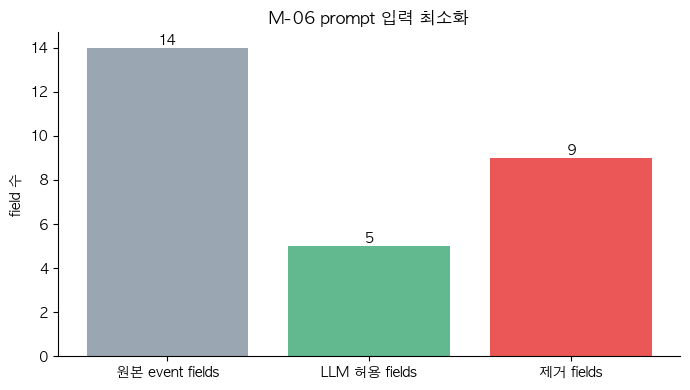

In [6]:
raw_field_count = len(sample_events[0])
allowed_field_count = len(ALLOWED_EVENT_FIELDS)
removed_field_count = raw_field_count - allowed_field_count

fig, axis = plt.subplots(figsize=(7, 4))
bars = axis.bar(
    ["원본 event fields", "LLM 허용 fields", "제거 fields"],
    [raw_field_count, allowed_field_count, removed_field_count],
    color=["#9aa6b2", "#62b88f", "#eb5757"],
)
axis.bar_label(bars)
axis.set_ylabel("field 수")
axis.set_title("M-06 prompt 입력 최소화", fontweight="bold")
axis.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
display(fig)
plt.close(fig)


# 4. 선택적 Ollama 실행

기본값 `RUN_OLLAMA=False`에서는 network 요청을 만들지 않는다. Jetson 또는 Ollama가 설치된 개발 PC에서 직접 실행할 때만 값을 `True`로 바꾼다.


In [7]:
SYSTEM_PROMPT = (
    "Wardy 가정 안전 기록의 한국어 문장 편집기로 동작한다. "
    "고정 집계 문장을 바꾸지 말고, 제공된 이벤트명·위치 외의 의료 진단, "
    "사고 확정, 위험 추측, 행동 지시, 시간, 이름, 식별자, 사진, 영상을 추가하지 않는다."
)

def request_ollama(prompt: str) -> tuple[str, float]:
    payload = {
        "model": MODEL_NAME,
        "system": SYSTEM_PROMPT,
        "prompt": prompt,
        "stream": False,
        "think": False,
        "keep_alive": "0s",
        "format": {"type": "object", "properties": {"summary": {"type": "string"}}, "required": ["summary"]},
        "options": {"num_ctx": 2048, "num_predict": 100, "temperature": 0, "seed": 7},
    }
    http_request = request.Request(
        OLLAMA_URL,
        data=json.dumps(payload).encode("utf-8"),
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    started = time.perf_counter()
    with request.urlopen(http_request, timeout=OLLAMA_TIMEOUT_SECONDS) as response:
        body = json.loads(response.read().decode("utf-8"))
    generated = json.loads(body["response"])["summary"]
    return generated, (time.perf_counter() - started) * 1000.0

generated_summary = None
ollama_latency_ms = None
if RUN_OLLAMA:
    generated_summary, ollama_latency_ms = request_ollama(anonymized_prompt)
    print(generated_summary)
    print(f"Ollama latency: {ollama_latency_ms:.1f} ms")
else:
    print("RUN_OLLAMA=False: local LLM 호출을 건너뜁니다.")


RUN_OLLAMA=False: local LLM 호출을 건너뜁니다.


# 5. 출력 검증과 fallback

현재 production 계약은 LLM이 고정 집계 문장으로 시작했는지 검증한 뒤 사용자에게는 검증된 deterministic summary를 제공한다. 뒤에 생성된 설명이 있으면 `filtered=True`로 기록하고 제거한다. Ollama 오류·비활성·형식 오류에서도 같은 집계가 유지된다.


In [8]:
def validate_generated_summary(generated: str | None, fallback: str) -> dict[str, object]:
    if generated is None:
        return {"summary": fallback, "fallback": True, "filtered": False, "reason": "unavailable"}
    if not generated.startswith(fallback):
        return {"summary": fallback, "fallback": True, "filtered": False, "reason": "invalid_output"}
    return {"summary": fallback, "fallback": False, "filtered": generated != fallback, "reason": None}

contract_cases = {
    "정상": fixed_summary,
    "추가 문장": fixed_summary + " 거실에서 이벤트가 관찰되었습니다.",
    "고정 집계 변경": "오늘 위험한 사고가 확정되었습니다.",
    "Ollama unavailable": None,
}
contract_results = {name: validate_generated_summary(value, fixed_summary) for name, value in contract_cases.items()}
for name, result in contract_results.items():
    print(name, result)

assert contract_results["정상"]["fallback"] is False
assert contract_results["추가 문장"]["filtered"] is True
assert contract_results["고정 집계 변경"]["reason"] == "invalid_output"
assert contract_results["Ollama unavailable"]["reason"] == "unavailable"


정상 {'summary': '오늘 총 2건의 안전 확인 이벤트가 기록되었습니다. 정상 0건, 주의 1건, 경고 1건, 긴급 0건이며 미확인 1건입니다.', 'fallback': False, 'filtered': False, 'reason': None}
추가 문장 {'summary': '오늘 총 2건의 안전 확인 이벤트가 기록되었습니다. 정상 0건, 주의 1건, 경고 1건, 긴급 0건이며 미확인 1건입니다.', 'fallback': False, 'filtered': True, 'reason': None}
고정 집계 변경 {'summary': '오늘 총 2건의 안전 확인 이벤트가 기록되었습니다. 정상 0건, 주의 1건, 경고 1건, 긴급 0건이며 미확인 1건입니다.', 'fallback': True, 'filtered': False, 'reason': 'invalid_output'}
Ollama unavailable {'summary': '오늘 총 2건의 안전 확인 이벤트가 기록되었습니다. 정상 0건, 주의 1건, 경고 1건, 긴급 0건이며 미확인 1건입니다.', 'fallback': True, 'filtered': False, 'reason': 'unavailable'}


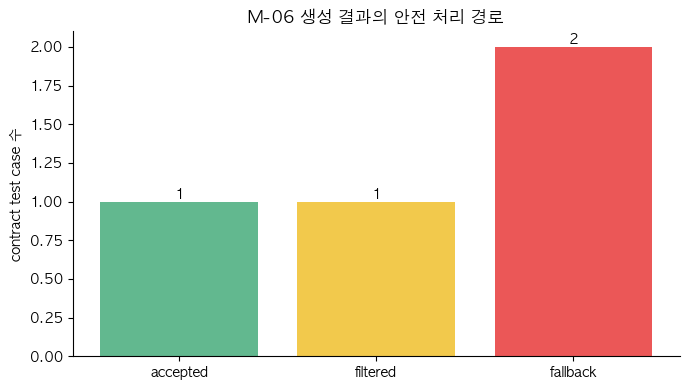

In [9]:
outcomes = Counter(
    "filtered" if result["filtered"] else "fallback" if result["fallback"] else "accepted"
    for result in contract_results.values()
)
fig, axis = plt.subplots(figsize=(7, 4))
labels = ["accepted", "filtered", "fallback"]
bars = axis.bar(labels, [outcomes[label] for label in labels], color=["#62b88f", "#f2c94c", "#eb5757"])
axis.bar_label(bars)
axis.set_ylabel("contract test case 수")
axis.set_title("M-06 생성 결과의 안전 처리 경로", fontweight="bold")
axis.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
display(fig)
plt.close(fig)


M-06은 개인정보를 뺀 구조화된 정보만 local LLM에 전달하고, 생성 결과가 기준을 벗어나거나 Ollama가 멈춰도 미리 계산한 안전 요약으로 돌아간다.
